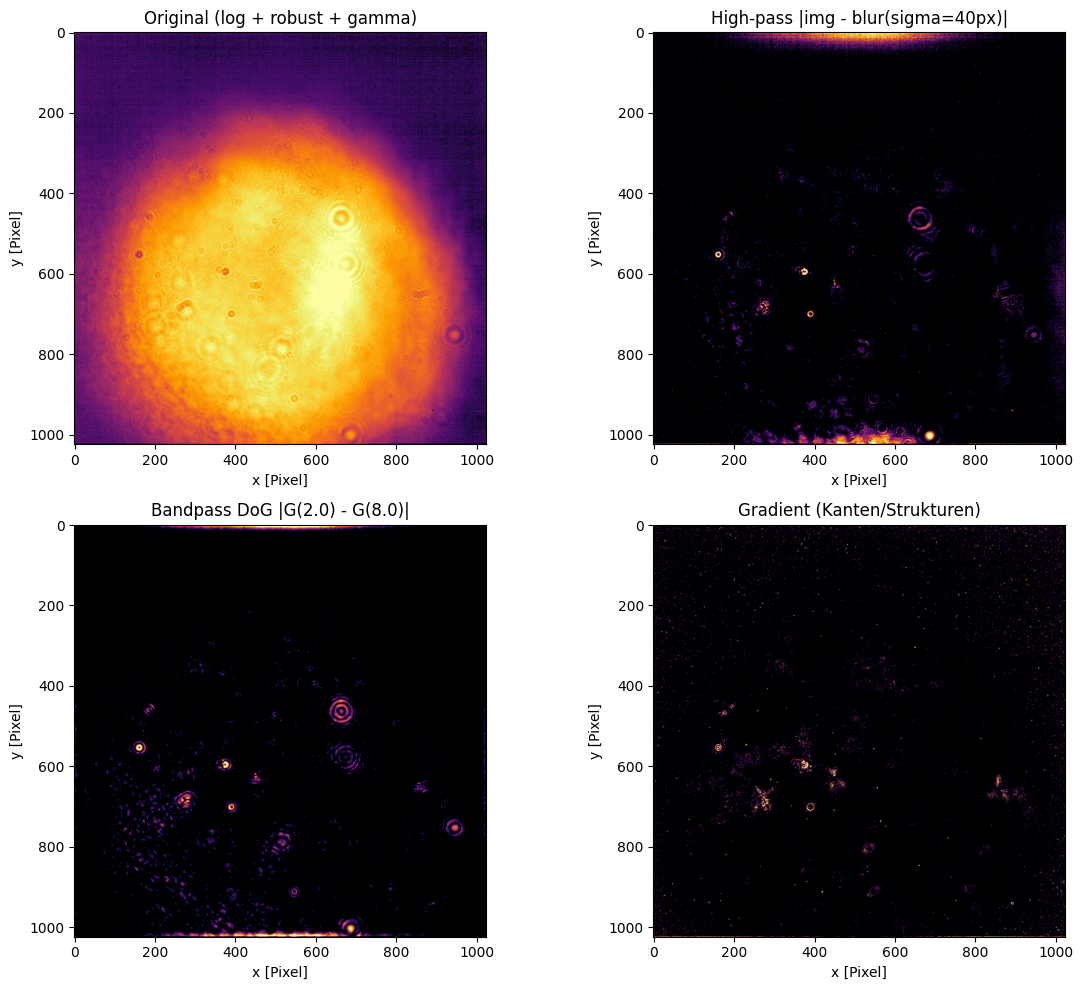

In [2]:
import numpy as np
import matplotlib.pyplot as plt

filename = "messung 750cm.tiff"

# -----------------------------
# TIFF laden
# -----------------------------
try:
    import tifffile
    img = tifffile.imread(filename)
except Exception:
    from PIL import Image
    img = np.array(Image.open(filename))

img = np.asarray(img)

# RGB → Grauwert
if img.ndim == 3:
    if img.shape[-1] in (3, 4):
        img = img[..., :3].mean(axis=-1)
    else:
        img = img[0]

img = img.astype(np.float64)

# -----------------------------
# Helper: robust normalize
# -----------------------------
def robust_norm(a, pmin=0.5, pmax=99.5):
    lo, hi = np.percentile(a, [pmin, pmax])
    if hi <= lo:
        return np.zeros_like(a)
    out = (a - lo) / (hi - lo)
    return np.clip(out, 0, 1)

# -----------------------------
# Helper: fast gaussian blur via FFT (NumPy-only)
# -----------------------------
def gaussian_blur_fft(a, sigma_px):
    """Gaussian blur (approx) using FFT. sigma_px in pixels."""
    if sigma_px <= 0:
        return a.copy()

    h, w = a.shape
    fy = np.fft.fftfreq(h)  # cycles per pixel
    fx = np.fft.fftfreq(w)
    FX, FY = np.meshgrid(fx, fy)

    # Gaussian transfer function: exp(-2*pi^2*sigma^2*(fx^2+fy^2))
    H = np.exp(-2 * (np.pi**2) * (sigma_px**2) * (FX**2 + FY**2))

    A = np.fft.fft2(a)
    return np.fft.ifft2(A * H).real

# -----------------------------
# 1) Grundbild: Log + robust display
# -----------------------------
img_log = np.log1p(img)
base = robust_norm(img_log, 1, 99)

# -----------------------------
# 2) Hintergrund entfernen: High-pass (img - blur)
#    -> zeigt feine Ringe besser
# -----------------------------
sigma_bg = 40   # Pixel: größer = mehr "grobe Hülle" wird entfernt
bg = gaussian_blur_fft(img_log, sigma_bg)
hp = img_log - bg

# Symmetrisch clippen (weil hp auch negativ ist)
hp_abs = np.abs(hp)
hp_disp = robust_norm(hp_abs, 90, 99.9)  # betont nur stärkere Strukturen

# Alternative: signed high-pass (nur positive Anteile)
hp_pos = np.maximum(hp, 0)
hp_pos_disp = robust_norm(hp_pos, 95, 99.9)

# -----------------------------
# 3) Bandpass (Difference of Gaussians): Ringe bestimmter Größe
# -----------------------------
sigma1 = 2.0
sigma2 = 8.0
dog = gaussian_blur_fft(img_log, sigma1) - gaussian_blur_fft(img_log, sigma2)
dog_abs = np.abs(dog)
dog_disp = robust_norm(dog_abs, 92, 99.9)

# -----------------------------
# 4) "Kanten" Ansicht (Sobel-ähnlich, NumPy only)
# -----------------------------
# einfache Gradienten (finite differences)
gy = np.zeros_like(img_log)
gx = np.zeros_like(img_log)
gy[1:-1, :] = (img_log[2:, :] - img_log[:-2, :]) * 0.5
gx[:, 1:-1] = (img_log[:, 2:] - img_log[:, :-2]) * 0.5
grad = np.hypot(gx, gy)
grad_disp = robust_norm(grad, 95, 99.9)

# -----------------------------
# 5) Optional: Gamma zur Betonung dunkler Details
# -----------------------------
gamma = 0.6  # <1 hebt dunkle Bereiche stärker an
base_gamma = np.power(base, gamma)

# -----------------------------
# Plot: 2x2 Übersicht
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].imshow(base_gamma, cmap="inferno", origin="upper")
axs[0, 0].set_title("Original (log + robust + gamma)")
axs[0, 0].set_xlabel("x [Pixel]")
axs[0, 0].set_ylabel("y [Pixel]")

axs[0, 1].imshow(hp_disp, cmap="inferno", origin="upper")
axs[0, 1].set_title(f"High-pass |img - blur(sigma={sigma_bg}px)|")
axs[0, 1].set_xlabel("x [Pixel]")
axs[0, 1].set_ylabel("y [Pixel]")

axs[1, 0].imshow(dog_disp, cmap="inferno", origin="upper")
axs[1, 0].set_title(f"Bandpass DoG |G({sigma1}) - G({sigma2})|")
axs[1, 0].set_xlabel("x [Pixel]")
axs[1, 0].set_ylabel("y [Pixel]")

axs[1, 1].imshow(grad_disp, cmap="inferno", origin="upper")
axs[1, 1].set_title("Gradient (Kanten/Strukturen)")
axs[1, 1].set_xlabel("x [Pixel]")
axs[1, 1].set_ylabel("y [Pixel]")

plt.tight_layout()
plt.show()

# -----------------------------
# Extra: einzelne Ansicht, falls du nur eine willst:
# plt.figure(figsize=(6,5))
# plt.imshow(dog_disp, cmap="inferno", origin="upper")
# plt.colorbar()
# plt.title("DoG Bandpass (Ringe betont)")
# plt.show()
# -----------------------------
